# 0. Load Data

In [ ]:
"""0. Load Data Used to Fine-Tune scGPT model

Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import sys
import os, numpy as np
import json
import h5py, scanpy as sc
sys.path.append("../..")
from src.utils import io 
import pandas as pd
from src.utils import viz as vz
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import cm
import sys
from src.training import helpers as tr_h
import random
import seaborn as sns
import importlib
import anndata as ad

importlib.reload(tr_h)

# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01")
run_dir = None
data_path = "/aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad"
gene_filtering = "top_presence"
# functions
def plot_adata_kde(adata:sc.AnnData, title:str="", sample_size:int=100, dpi=300)->None:
    plt.figure(figsize=(3, 3), dpi=dpi)
    for lib in adata.obs["library"].unique():
        X = adata[adata.obs["library"] == lib].X
        print("Nº of points", X.shape)
        print("Nº of GEx points", X.flatten().shape)
    
        # sample from both distributions
        X_sample = random.sample(list(X.flatten()), sample_size)

        # plot
        sns.kdeplot(X_sample, label=lib, fill=True, color="#2778ffff", alpha=0.6, edgecolor="#022778ff")

    plt.title(title)
    plt.legend()

def summarize_adata(adata:sc.AnnData)->pd.DataFrame:
    
    X = np.array(adata.X)

    # how many samples
    n_disease_samples = adata[adata.obs["disease"] != "Control"].shape[0]
    n_control_samples = adata[adata.obs["disease"] == "Control"].shape[0]

    # how many samples per library stratergy
    n_rna_seq_samples = adata[adata.obs["library"] == "RNA-Seq"].shape[0]
    n_ma_seq_samples = adata[adata.obs["library"] == "Microarray"].shape[0]


    # how many genes
    n_genes = X.shape[1] - np.isnan(X).sum(axis=0)

    # how many datasets
    n_datasets = adata.obs['dataset'].nunique()

    # how many diseases
    n_diseases = adata[adata.obs["disease"] != "Control"].obs['do_id'].nunique()

    # how many samples per disease
    n_samples_per_disease = adata[adata.obs["disease"] != "Control"].obs['do_id'].value_counts().values

    # how many samples per dataset
    n_samples_per_dataset = adata.obs['dataset'].value_counts().values

    df_expl = pd.DataFrame({
        "Nº Datasets": [n_datasets],
        "Nº Diseases": [n_diseases],
        "Nº Samples Disease": [n_disease_samples],
        "Nº Samples Control": [n_control_samples],
        "Nº Samples RNA-Seq": [n_rna_seq_samples],
        "Nº Samples Microarray": [n_ma_seq_samples],
        "Nº Samples per Disease": [f"{np.mean(n_samples_per_disease):.0f} ± {np.std(n_samples_per_disease):.0f}"],
        "Nº Samples per Dataset": [f"{np.mean(n_samples_per_dataset):.0f} ± {np.std(n_samples_per_dataset):.0f}"],
        "Nº Genes per Sample": [f"{np.mean(n_genes):.0f} ± {np.std(n_genes):.0f}"],

    })
    return df_expl

# 2. Load Data

if run_dir is not None:
    split_idx = 0
    # load all adata
    adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
    )
    adata_test.obs.reset_index(drop=True, inplace=True)  
    adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
    )
    adata_valid.obs.reset_index(drop=True, inplace=True)  
    adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
    )
    adata = ad.concat([adata_train, adata_valid, adata_test]).shape
else:
    adata = sc.read_h5ad(data_path)

# filter by gene presence
    if gene_filtering == "top_presence":
        # get top k most present genes
        mask_genes = tr_h.get_top_k_most_present_genes(
                adata, k=3501
            )
        print(adata.shape)
        adata = adata[:, mask_genes]
        print(adata.shape)

    # clean dataset
    adata = tr_h.clean_adata_qc(adata)
    print(adata.shape)
    # perform combat analysis
    # adata_combat = tr_h.apply_combat_adata(adata)


    # mask samples
    nan_thr= 0.9

    non_nan_mask = ~np.isnan(adata.X)  & ~(adata.X==0) 
    non_nan_mask_pct = np.sum(non_nan_mask, axis=1) / adata.X.shape[1]

    # mask samples that have less than 30% non-NaN values
    mask_samples_nan = non_nan_mask_pct >= nan_thr 

    print(f"{nan_thr} Keeping {np.sum(mask_samples_nan)} samples out of {adata.X.shape[0]} ({np.sum(mask_samples_nan)/adata.X.shape[0]*100:.2f}%)")


    zero_thr = 0.5
    non_zero_mask = ~(adata.X==0) 
    non_zero_mask_pct = np.sum(non_zero_mask, axis=1) / adata.X.shape[1]

    # mask samples that have less than 30% non-NaN values
    mask_samples_zero = non_zero_mask_pct >= zero_thr 

    mask_samples_comb = mask_samples_nan & mask_samples_zero

    adata_gen = adata[mask_samples_comb, :]

    # filter by library
    # only rnaseq
    # adata_lib = adata_gen[adata_gen.obs["library"] == "RNA-Seq"]
    adata_lib = adata_gen[adata_gen.obs["library"] == "Microarray"]
    # adata_lib = adata_gen
    print(adata_lib.shape)

    # filter redundancy
    adata_nr = tr_h.clean_redundancy(adata_lib)
    print(adata_nr.shape)

    # filter by enough datasets & samples
    adata_clean = tr_h.clean_adata_qc(adata_nr)
    print(adata_clean.shape)



# 3. Exploratory Analysis
summarize_adata(adata)


INFO:root:Nº genes: 20608, Nº samples: 121142
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
INFO:root:Top 3501 most present genes selected. - >= 117469


(121142, 20608)
(121142, 3501)
Nº of failed datasets - less than +2 control samples: 0
Nº of failed datasets - less than +2 disease samples: 0
Nº of failed datasets - less than +2 samples (control and disease): 0 / 2140
adata shape after filtering datasets with +2 samples: (121142, 3501)
Nº of passed diseases +2 296/ 296
Nº of passed dsaids +2 3986/ 3986
(121142, 3501)
0.9 Keeping 110676 samples out of 121142 (91.36%)
(73611, 3501)
Removed samples in multiple datasets, new shape: (72636, 3501)
Removed duplicate samples, new shape: (59959, 3501)
Removed duplicate samples independent of disease, new shape: (59243, 3501)
(59243, 3501)
Nº of failed datasets - less than +2 control samples: 2
Nº of failed datasets - less than +2 disease samples: 0
Nº of failed datasets - less than +2 samples (control and disease): 2 / 1248
adata shape after filtering datasets with +2 samples: (59241, 3501)
Nº of passed diseases +2 208/ 266
Nº of passed dsaids +2 2202/ 2321
(56728, 3501)


,Nº Datasets,Nº Diseases,Nº Samples Disease,Nº Samples Control,Nº Samples RNA-Seq,Nº Samples Microarray,Nº Samples per Disease,Nº Samples per Dataset,Nº Genes per Sample
0,2140,296,69304,51838,41234,79908,234 ± 436,57 ± 118,633 ± 562


In [2]:
summarize_adata(adata_clean)

,Nº Datasets,Nº Diseases,Nº Samples Disease,Nº Samples Control,Nº Samples RNA-Seq,Nº Samples Microarray,Nº Samples per Disease,Nº Samples per Dataset,Nº Genes per Sample
0,1199,208,37358,19370,0,56728,180 ± 301,47 ± 66,3251 ± 270


# 1. Exploratory Plots

## 1.1 Distribution of Gene Expression Values 

Nº of points (56728, 3501)
Nº of GEx points (198604728,)


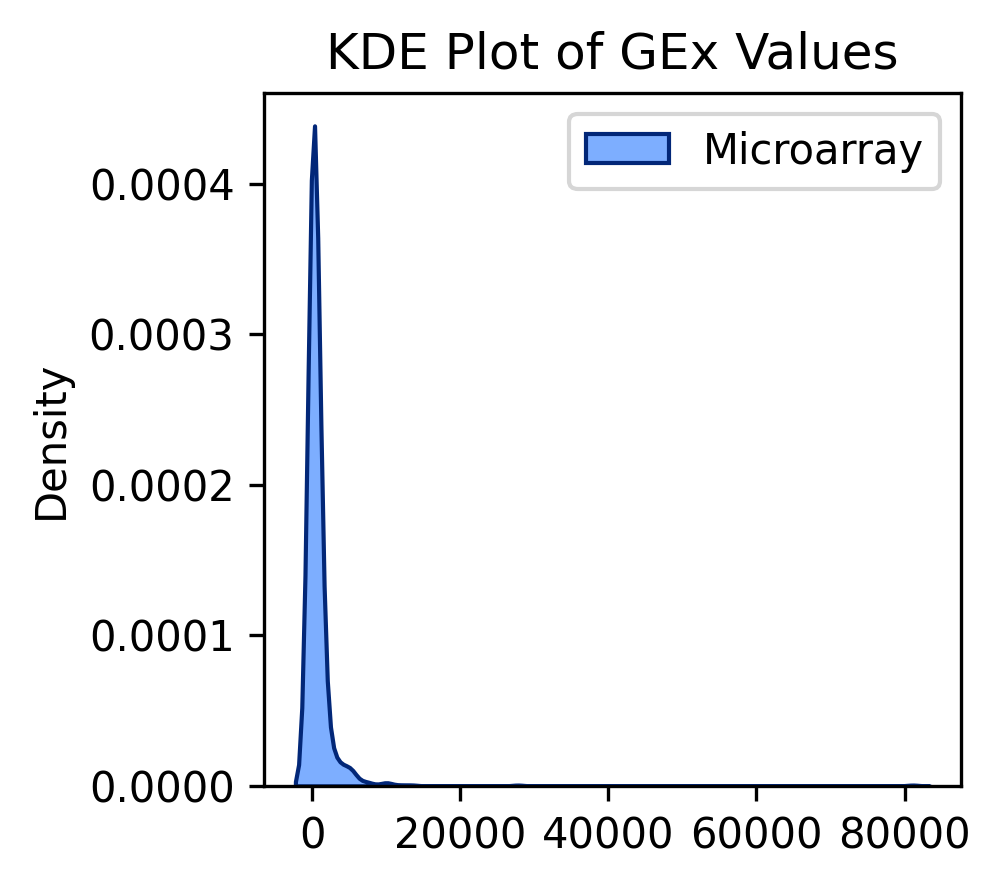

In [3]:
# plot GEx distribution
plot_adata_kde(adata_clean, title="KDE Plot of GEx Values", sample_size=1000)

## 1.2 Main Diseases & Families

In [20]:
importlib.reload(vz)

<module 'src.utils.viz' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/pipeline/../../src/utils/viz.py'>

Number of DO leaves: 9018
Generated multilabel vectors for level 1 nodes with shape (121142, 51)
Cleaned multilabel vectors for top 50 nodes with shape (121142, 50)
51838 samples	Node Control
2014 samples	Node DOID:0014667 - disease of metabolism
2352 samples	Node DOID:0050117 - disease by infectious agent
696 samples	Node DOID:0050155 - sensory system disease
1728 samples	Node DOID:0050177 - monogenic disease
26318 samples	Node DOID:0050686 - organ system cancer
19238 samples	Node DOID:0050687 - cell type cancer
165 samples	Node DOID:0050735 - X-linked monogenic disease
468 samples	Node DOID:0050736 - autosomal dominant disease
1042 samples	Node DOID:0050737 - autosomal recessive disease
1510 samples	Node DOID:0050739 - autosomal genetic disease
21 samples	Node DOID:0060037 - developmental disorder of mental health
887 samples	Node DOID:0060072 - benign neoplasm
276 samples	Node DOID:0060084 - cell type benign neoplasm
838 samples	Node DOID:0060085 - organ system benign neoplasm
1029 

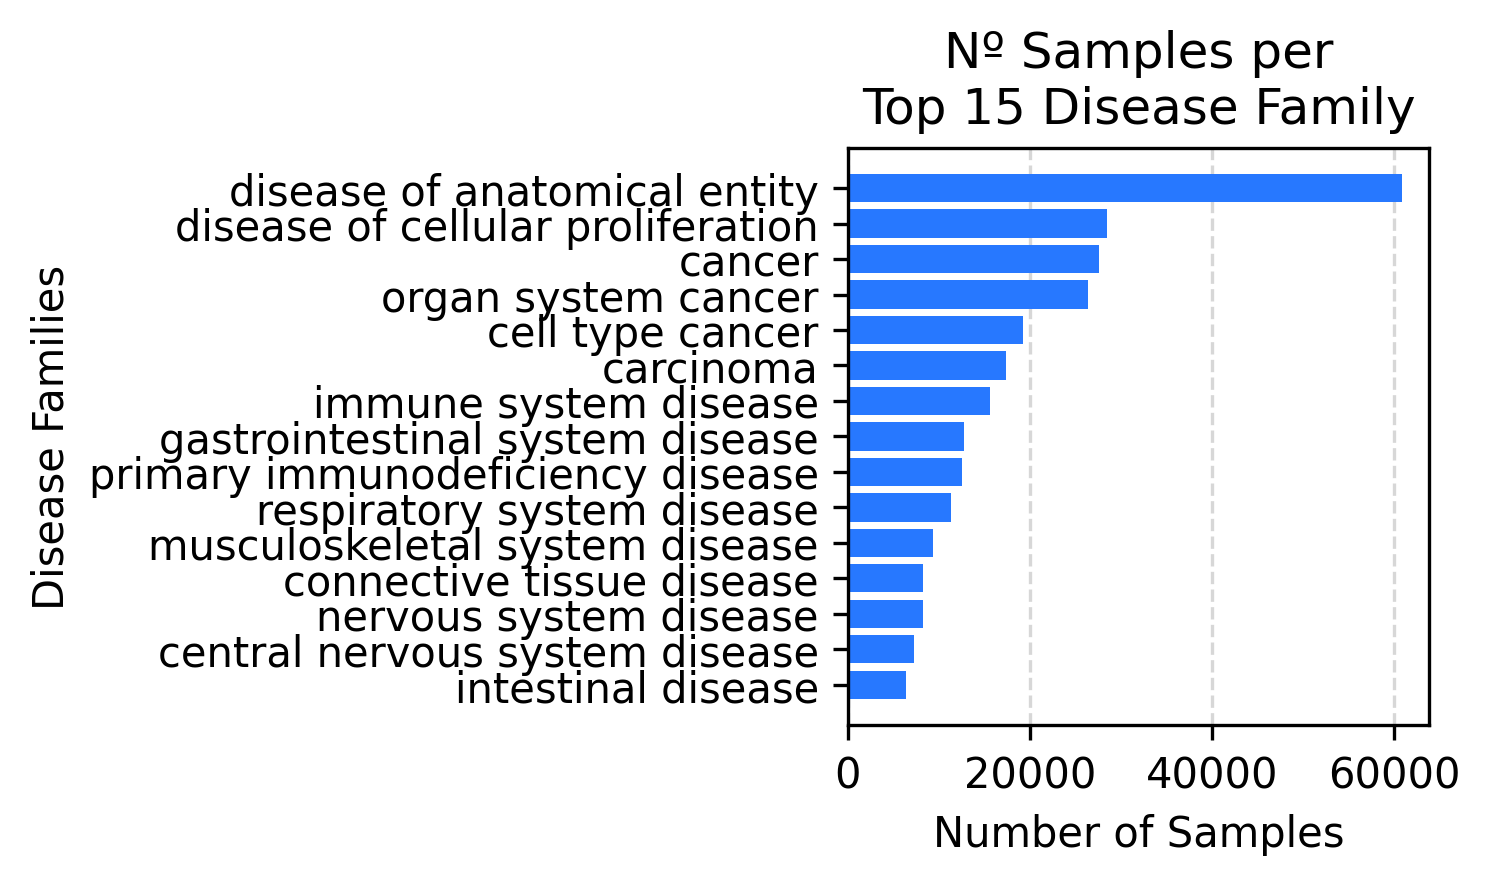

In [21]:
vz.plot_adata_top_families(adata, n_class_nodes=50, top_n=15, dpi=300)

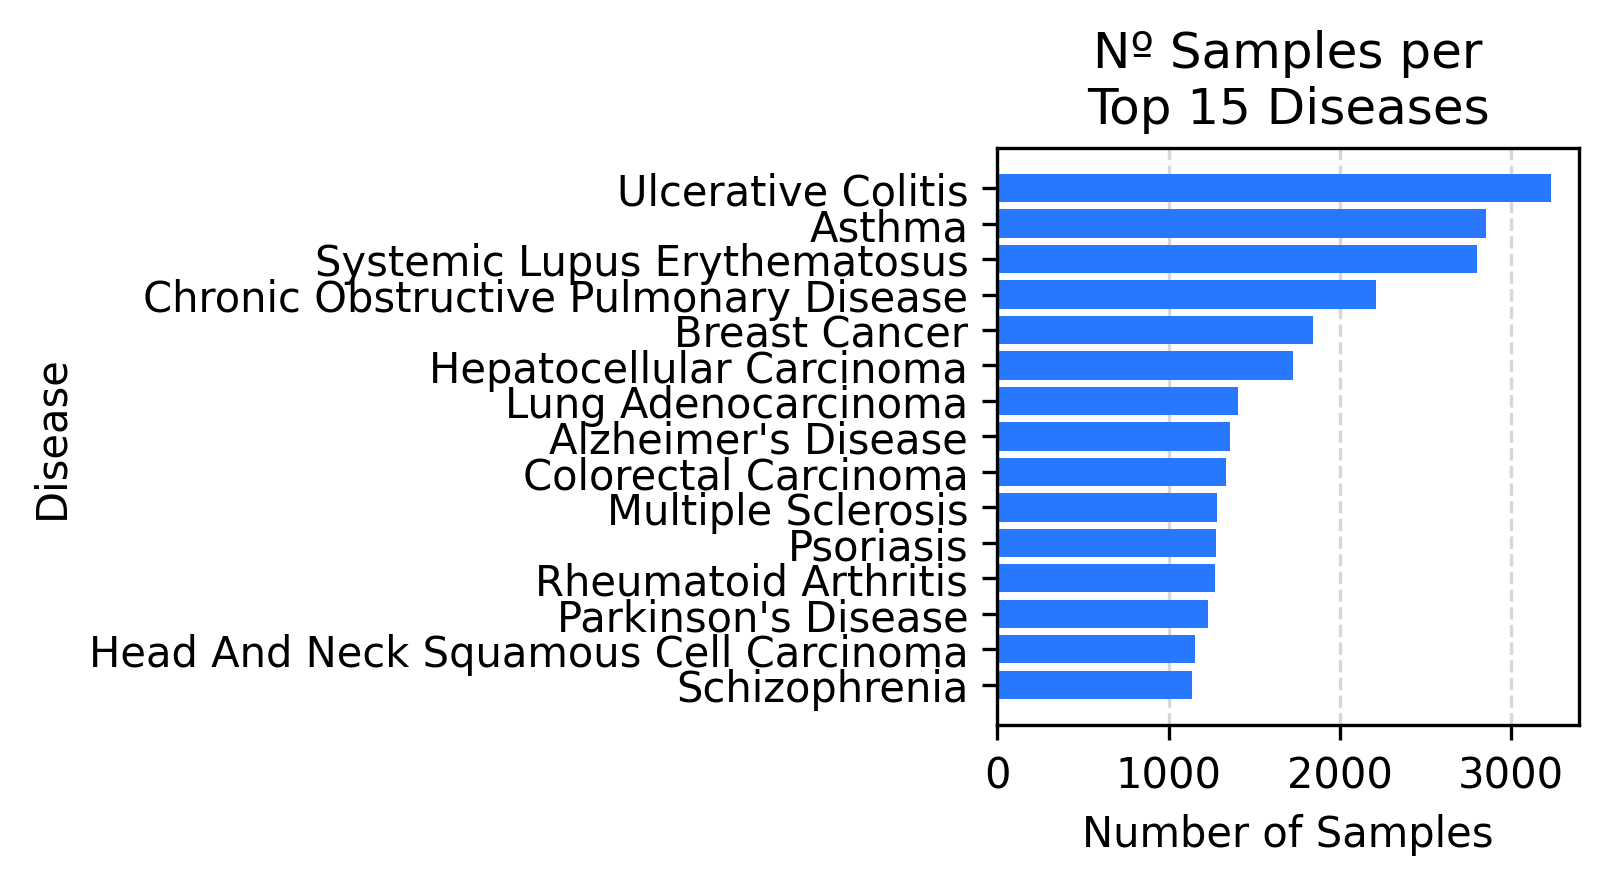

In [19]:
from collections import Counter
def plot_adata_top_diseases(adata, top_n:int=None, dpi:int=150)->None:

    counts_dis = adata.obs['disease'].value_counts().to_dict()

    # clean
    counts_dis = {k:v for k, v in counts_dis.items() if (v > 0)& (k.lower() != "control")}

    # sort in descending order
    counts_dis = dict(sorted(counts_dis.items(), key=lambda item: item[1], reverse=False))

    # plot horizontal histogram of counts of main families
    plt.figure(figsize=(2.5, 2.5), dpi=dpi)
    if top_n:
        plt.barh(list(counts_dis.keys())[-top_n:], list(counts_dis.values())[-top_n:],zorder=2,color="#2778ffff", alpha=1)
        plt.title(f"Nº Samples per\nTop {top_n} Diseases")
    else:
        plt.barh(list(counts_dis.keys()), list(counts_dis.values()),zorder=2,color="#2778ffff", alpha=1)
        plt.title("Nº Samples per Disease")
    plt.xlabel("Number of Samples")
    plt.ylabel("Disease")
    plt.grid(linestyle="--", zorder=-1, alpha=0.5, axis="x")
    plt.show()

plot_adata_top_diseases(adata, top_n=15, dpi=300)

In [6]:
adata_clean.obs

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,sample_id
60,DSA00042.GSM185811.Control,GSE7670,GSE7670,61,61,DSA00042,Lung,12004,Control,Control,Lung Adenocarcinoma,Microarray,D,Control,Control,Control,GSM185811
61,DSA00042.GSM185813.Control,GSE7670,GSE7670,61,61,DSA00042,Lung,12004,Control,Control,Lung Adenocarcinoma,Microarray,D,Control,Control,Control,GSM185813
62,DSA00042.GSM185815.Control,GSE7670,GSE7670,61,61,DSA00042,Lung,12004,Control,Control,Lung Adenocarcinoma,Microarray,D,Control,Control,Control,GSM185815
63,DSA00042.GSM185817.Control,GSE7670,GSE7670,61,61,DSA00042,Lung,12004,Control,Control,Lung Adenocarcinoma,Microarray,D,Control,Control,Control,GSM185817
64,DSA00042.GSM185819.Control,GSE7670,GSE7670,61,61,DSA00042,Lung,12004,Control,Control,Lung Adenocarcinoma,Microarray,D,Control,Control,Control,GSM185819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121137,DSA10302.GSM139471.Case,GSE6008,GSE6008,1509,1509,DSA10302,Ovary,12004,Ovarian Tumor,Ovarian Tumor,Ovarian Tumor,Microarray,D,DOID:2394,DOID:2394,ovarian cancer,GSM139471
121138,DSA10302.GSM139472.Case,GSE6008,GSE6008,1509,1509,DSA10302,Ovary,12004,Ovarian Tumor,Ovarian Tumor,Ovarian Tumor,Microarray,D,DOID:2394,DOID:2394,ovarian cancer,GSM139472
121139,DSA10302.GSM139473.Case,GSE6008,GSE6008,1509,1509,DSA10302,Ovary,12004,Ovarian Tumor,Ovarian Tumor,Ovarian Tumor,Microarray,D,DOID:2394,DOID:2394,ovarian cancer,GSM139473
121140,DSA10302.GSM139474.Case,GSE6008,GSE6008,1509,1509,DSA10302,Ovary,12004,Ovarian Tumor,Ovarian Tumor,Ovarian Tumor,Microarray,D,DOID:2394,DOID:2394,ovarian cancer,GSM139474


## 1.3 tSNE values

In [22]:
# generate tSNE data
X_tsne, adata_tsne = vz.transform_tsne(adata_clean)

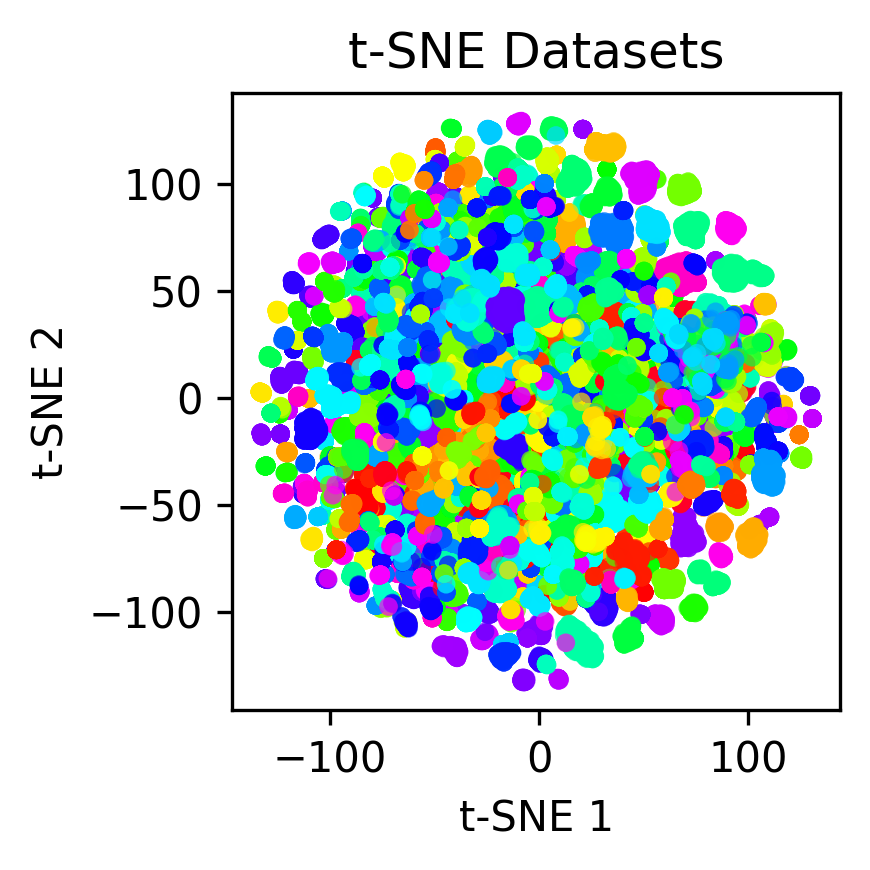

In [23]:
# plot tSNE tissue
vz.plot_tsne_adata(X_tsne, adata_tsne, "dataset", title="t-SNE Datasets")

/tmp/ipykernel_1657810/320789434.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_tsne.obs["tissue"].fillna("unknown", inplace=True)


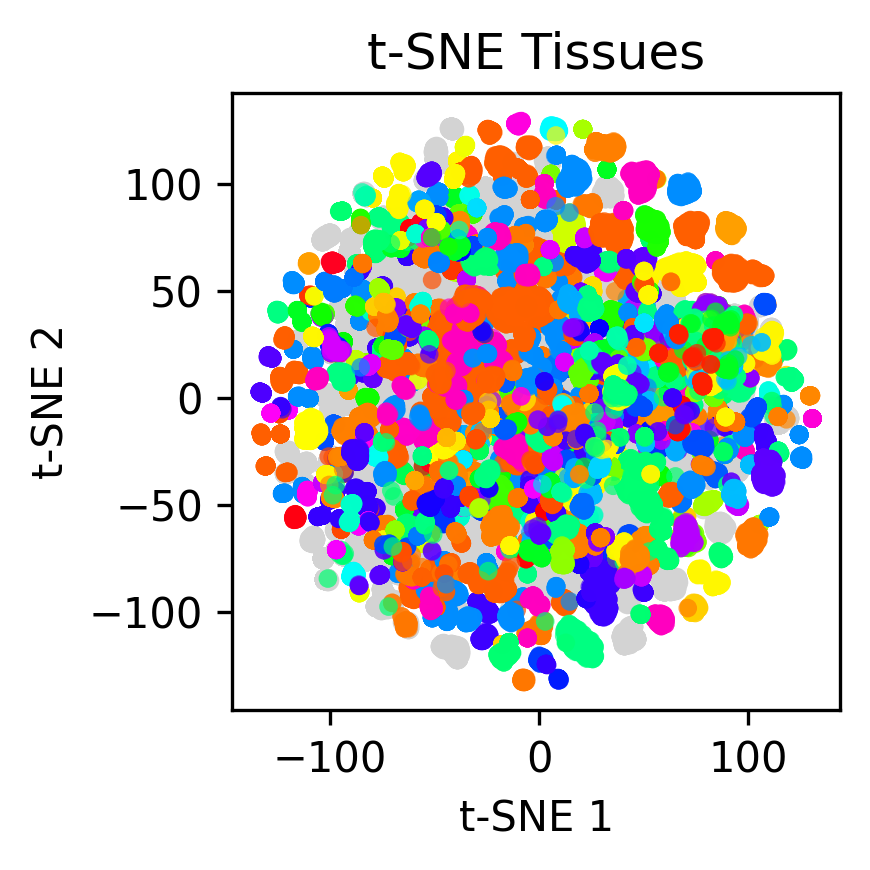

In [24]:
# add tissue info
from src.utils import utils as ut
df_info = ut.load_dsa_info()
dsaid_2_tissue = dict(zip(df_info["dsaid"], df_info["tissue"]))


adata_tsne.obs["tissue"] = adata_tsne.obs["dsaid"].map(dsaid_2_tissue)

# replace nans
adata_tsne.obs["tissue"].fillna("unknown", inplace=True)
adata_tsne.obs["tissue"] = adata_tsne.obs["tissue"].astype("category")
vz.plot_tsne_adata(X_tsne, adata_tsne, "tissue", title="t-SNE Tissues")

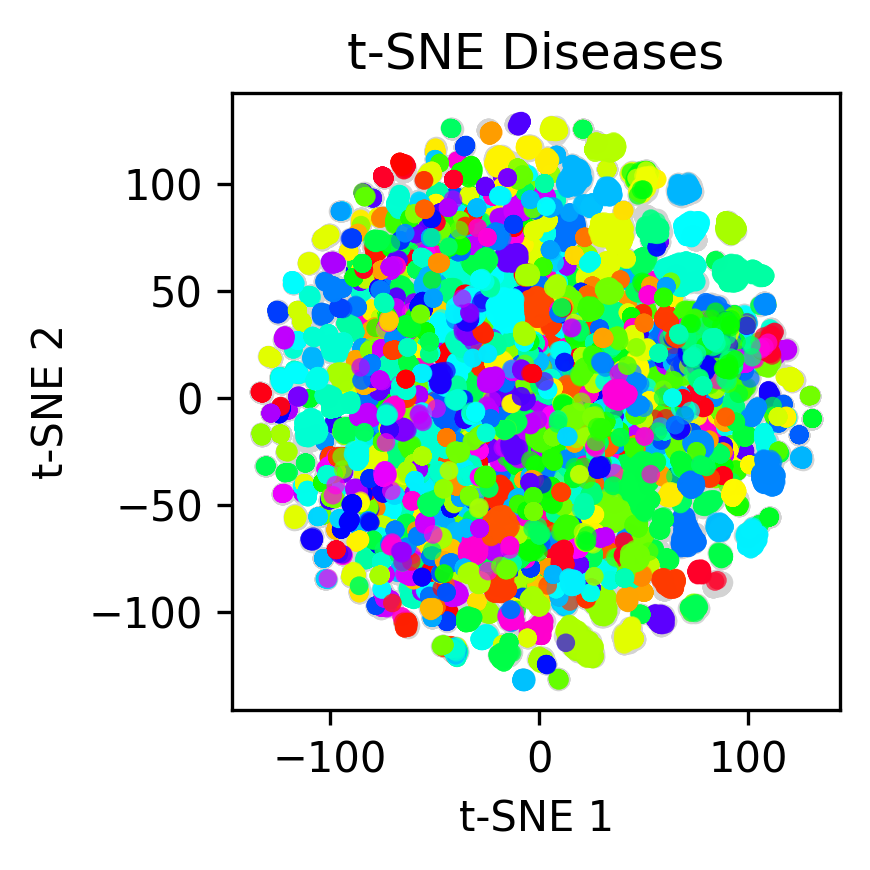

In [25]:
vz.plot_tsne_adata(X_tsne, adata_tsne, "doid_id", title="t-SNE Diseases")

## Data Filtering Plots

In [26]:
import sys
sys.path.append("../..")
from src.utils import utils as ut
df_info = ut.load_dsa_info()

counts = df_info["control_case_sample_count"].values
all_counts = [int(c.split("|")[0]) + int(c.split("|")[1]) for c in counts if "|" in c]
control_s = [int(c.split("|")[0]) for c in counts if "|" in c]
disease_s = [int(c.split("|")[1]) for c in counts if "|" in c]
df_info = df_info.copy()
df_info["total_counts"] = all_counts
df_info["control_counts"] = control_s
df_info["disease_counts"] = disease_s

# filter by bulk
df_info = df_info.query(f"library_strategy in ['RNA-Seq' , 'Microarray']")
s_0 = df_info["total_counts"].sum()
ds_0 = df_info["disease_counts"].sum()
c_0 = df_info["control_counts"].sum()
d_0 = df_info["diseaseid"].nunique()
dt_0 = df_info["accession"].nunique()

# filter by species
df_info = df_info.query(f"organism == 'Homo sapiens'")
s_1 = df_info["total_counts"].sum()
ds_1 = df_info["disease_counts"].sum()
c_1 = df_info["control_counts"].sum()
d_1 = df_info["diseaseid"].nunique()
dt_1 = df_info["accession"].nunique()

# filter by mapping
_do_g = ut.load_do_graph()
_uml_2_doid = ut.get_umls_2_doid_mapping(_do_g)
df_info = df_info.query(f"diseaseid in {list(_uml_2_doid.keys())}")
s_2 = df_info["total_counts"].sum()
ds_2 = df_info["disease_counts"].sum()
c_2 = df_info["control_counts"].sum()
d_2 = df_info["diseaseid"].nunique()
dt_2 = df_info["accession"].nunique()

# filter by library stratergy
# df_info = df_info.query(f"library_strategy in ['RNA-Seq']")
# s_3 = df_info["total_counts"].sum()
# ds_3 = df_info["disease_counts"].sum()
# c_3 = df_info["control_counts"].sum()
# d_3 = df_info["diseaseid"].nunique()
# dt_3 = df_info["accession"].nunique()
s_3 = adata_lib.X.shape[0]
ds_3 = np.sum([adata_lib.obs["doid_id"] != "Control"])
c_3 = np.sum([adata_lib.obs["doid_id"] == "Control"])
d_3 = adata_lib.obs["doid_id"].nunique() - 1 # remove control
dt_3 = adata_lib.obs["dataset"].nunique()


# filter by UNIQUE SAMPLES
s_4 = adata_nr.X.shape[0]
ds_4 = np.sum([adata_nr.obs["doid_id"] != "Control"])
c_4 = np.sum([adata_nr.obs["doid_id"] == "Control"])
d_4 = adata_nr.obs["doid_id"].nunique() - 1 # remove control
dt_4 = adata_nr.obs["dataset"].nunique()

# filter by QC CLEANING
s_5 = adata_clean.X.shape[0]
ds_5 = np.sum([adata_clean.obs["doid_id"] != "Control"])
c_5 = np.sum([adata_clean.obs["doid_id"] == "Control"])
d_5 = adata_clean.obs["doid_id"].nunique() - 1 # remove control
dt_5 = adata_clean.obs["dataset"].nunique()

In [29]:
adata_clean.shape

(56728, 3501)

In [27]:
df_info["doid_id"] = df_info["diseaseid"].map(_uml_2_doid)

In [ ]:
df_info[""]

library_strategy
Microarray    3071
RNA-Seq       1610
Name: count, dtype: int64

0 231153 1405 4875


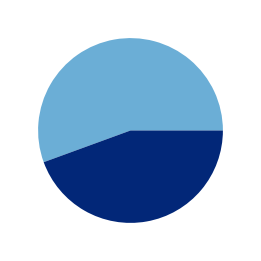

1 205395 1135 3544


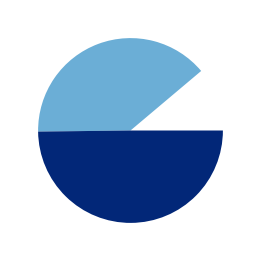

2 137539 591 2480


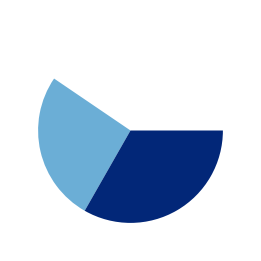

3 73611 267 1257


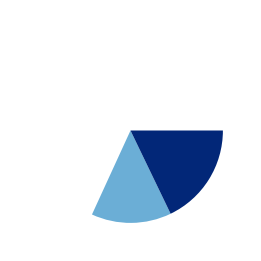

4 59243 266 1248


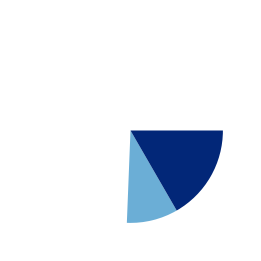

5 56728 208 1199


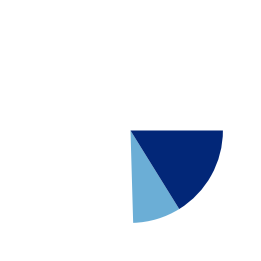

In [28]:
def plot_pie(x: list, colors:list, dpi:int=150):
    plt.figure(dpi=dpi, figsize=(2, 2))
    plt.pie(x, colors=colors, startangle=0)
    plt.show()
    
# plot pie charts
print(0, s_0, d_0, dt_0)
plot_pie([ds_0, c_0], colors=[ "#6baed6","#022778ff"])
print(1, s_1, d_1, dt_1)
plot_pie([s_0-(ds_1+c_1), c_1, ds_1], colors=["white", "#6baed6","#022778ff"])
print(2, s_2, d_2, dt_2)
plot_pie([s_0-(ds_2+c_2), c_2, ds_2], colors=["white", "#6baed6","#022778ff"])
print(3, s_3, d_3, dt_3)
plot_pie([s_0-(ds_3+c_3), c_3, ds_3], colors=["white", "#6baed6","#022778ff"])
print(4, s_4, d_4, dt_4)
plot_pie([s_0-(ds_4+c_4), c_4, ds_4], colors=["white", "#6baed6","#022778ff"])
print(5, s_5, d_5, dt_5)
plot_pie([s_0-(ds_5+c_5), c_5, ds_5], colors=["white", "#6baed6","#022778ff"])



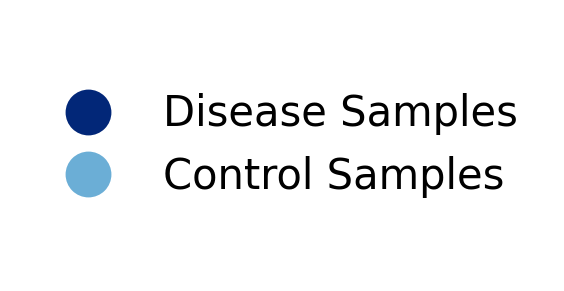

In [36]:
# Create an independent legend-only plot

fig, ax = plt.subplots(figsize=(2, 1), dpi=300)

# Turn off the axes
ax.axis("off")

# Define legend handles manually
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Disease Samples',
               markerfacecolor="#022778ff", markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Control Samples',
               markerfacecolor="#6baed6", markersize=12)
]

# Add the legend
ax.legend(handles=handles, loc="center", frameon=False)

plt.show()


# Disease Ontology Similarity Threshold

In [1]:
"""2. Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports
import sys
sys.path.append("../..")
from src.utils import utils as ut
import numpy as np
import pandas as pd
# variables

# functions


# 2. Load Disease Pairs

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215


In [ ]:
do_df_ic.query('lin>0.9').shape

(9264, 8)

In [ ]:
do_df_ic

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
0,DOID:0001816,DOID:0002116,"[DOID:0001816, DOID:0002116]",1.395206,0.143929,16.597073,DOID:7,9
1,DOID:0001816,DOID:0014667,"[DOID:0001816, DOID:0014667]",0.693147,0.107386,11.523194,DOID:4,6
2,DOID:0001816,DOID:0040001,"[DOID:0001816, DOID:0040001]",1.395206,0.146096,16.309391,DOID:7,11
3,DOID:0001816,DOID:0040002,"[DOID:0001816, DOID:0040002]",1.395206,0.141938,16.869007,DOID:7,8
4,DOID:0001816,DOID:0040003,"[DOID:0001816, DOID:0040003]",1.395206,0.140980,17.002539,DOID:7,9
...,...,...,...,...,...,...,...,...
70442510,DOID:9988,DOID:9993,"[DOID:9988, DOID:9993]",0.693147,0.073162,17.562109,DOID:4,10
70442511,DOID:9988,DOID:9997,"[DOID:9988, DOID:9997]",1.395206,0.133664,18.085883,DOID:7,10
70442512,DOID:999,DOID:9993,"[DOID:999, DOID:9993]",0.693147,0.075349,17.012063,DOID:4,9
70442513,DOID:999,DOID:9997,"[DOID:999, DOID:9997]",1.395206,0.137281,17.535837,DOID:7,9


In [2]:
data_do = list()
for thr_i in [0,0.1,0.2,0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    n_pairs = len(do_df_ic.query(f'lin>@thr_i'))
    n_unique_diseases = len(set(do_df_ic.query(f'lin>@thr_i')["do1"].values).union(
        set(do_df_ic.query(f'lin>@thr_i')["do2"].values)
    ))
    data_do.append({
        "Threshold": thr_i,
        "Nº Pairs": n_pairs,
        "Nº Unique Diseases": n_unique_diseases
    })

pd.DataFrame(data_do)

,Threshold,Nº Pairs,Nº Unique Diseases
0,0.00,70442515,11870
1,0.10,48692356,11870
2,0.20,19375919,11870
3,0.30,9964956,11870
4,0.40,3311180,11870
5,0.50,1101009,11750
6,0.60,385818,11459
7,0.70,134380,11212
8,0.80,39906,9773
9,0.90,9264,6597


In [ ]:
pd.DataFrame(data_do)

,Threshold,Nº Pairs,Nº Unique Diseases
0,0.10,48692356,11870
1,0.20,19375919,11870
2,0.30,9964956,11870
3,0.40,3311180,11870
4,0.50,1101009,11750
5,0.60,385818,11459
6,0.70,134380,11212
7,0.80,39906,9773
8,0.90,9264,6597
9,0.95,3041,3712


In [45]:
do_graph = ut.load_do_graph()

In [ ]:
do_df_ic.shape

(70442515, 8)

In [ ]:
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr'))}")

IC Threshold: 0.396	Nº of pairss 3518554


Text(0.5, 1.0, 'Disease Pair Similarities\nDistribution of Lin Similarity Scores')

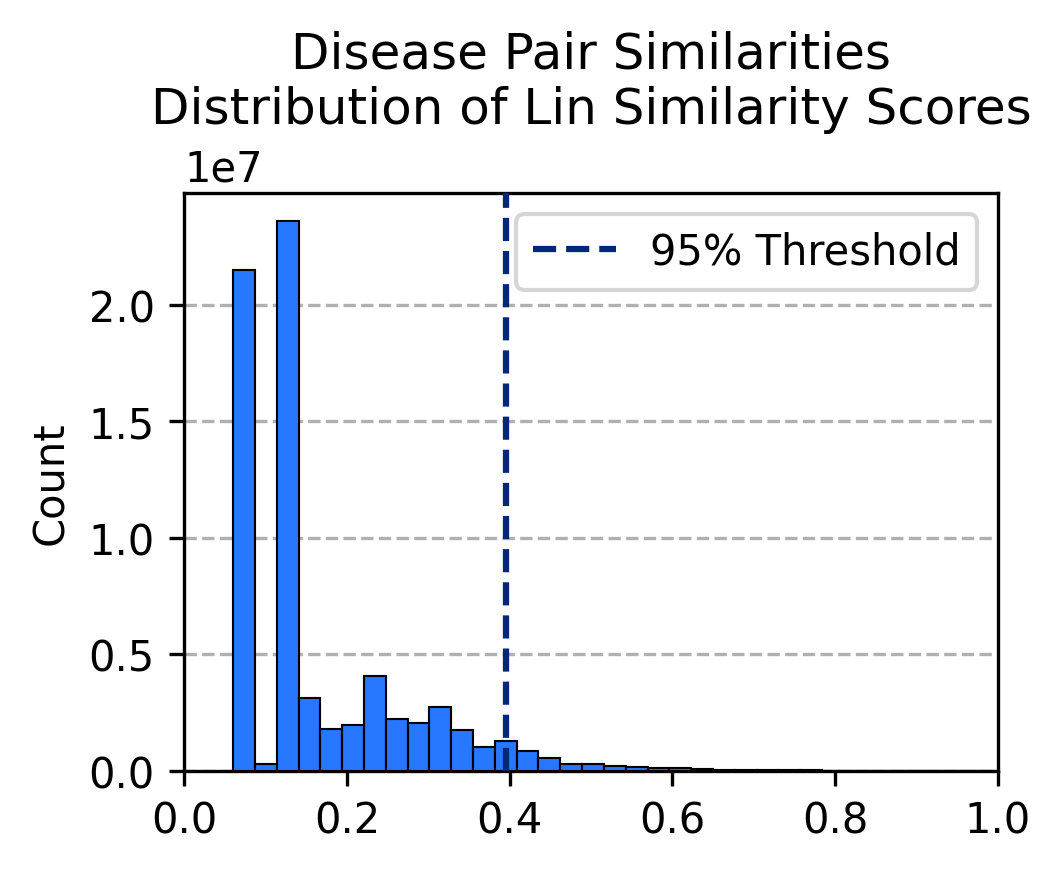

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import random
plt.figure(dpi=300, figsize=(3.5, 2.5))
sns.histplot(do_df_ic["lin"].to_list(), bins=35, alpha=1, kde=False, color="#2778ffff", edgecolor="black", zorder=3)
plt.axvline(ic_thr, color="#022778", linestyle="--", label="95% Threshold", zorder=4)
plt.grid(axis="y", zorder=-3, linestyle="--")
plt.legend()
plt.xlim(0, 1)
plt.title("Disease Pair Similarities\nDistribution of Lin Similarity Scores")

In [4]:
import networkx as nx

# --- 1) All nodes on ALL SHORTEST PATHS (undirected) ---
def connectors_shortest(G, u, v, use_undirected=True):
    H = G.to_undirected() if use_undirected else G
    paths = list(nx.all_shortest_paths(H, u, v))
    nodes = set().union(*map(set, paths))
    return nodes, paths

# --- 2) All nodes on ANY SIMPLE PATH up to a cutoff (undirected) ---
def connectors_simple(G, u, v, cutoff=10, use_undirected=True):
    H = G.to_undirected() if use_undirected else G
    paths = list(nx.all_simple_paths(H, u, v, cutoff=cutoff))
    nodes = set([u, v])
    for p in paths:
        nodes.update(p)
    return nodes, paths

# --- 3) “Ontology style”: go up to lowest common ancestor(s) and back ---
def lca_connectors(G, u, v):
    """
    For a DO DAG with edges child -> parent (is_a),
    return union of nodes on paths (u -> LCA) and (v -> LCA) for all LCAs.
    """
    # common ancestors
    anc_u = nx.ancestors(G, u)
    anc_v = nx.ancestors(G, v)
    common = anc_u & anc_v
    if not common:
        return set([u, v]), [], []

    # lowest common ancestors = common ancestors that have no descendant also in 'common'
    lcas = []
    for c in common:
        # c is "lowest" if no other node in common is reachable FROM c (excluding itself)
        if not any((m != c) and nx.has_path(G, c, m) for m in common):
            lcas.append(c)

    nodes = set([u, v])
    paths = []
    H = G.to_undirected()  # use undirected to get the path sequences
    for l in lcas:
        p_u = nx.shortest_path(H, u, l)
        p_v = nx.shortest_path(H, v, l)
        nodes.update(p_u)
        nodes.update(p_v)
        paths.extend([p_u, p_v])
    return nodes, lcas, paths

# --- optional: pretty-print with names stored on nodes ---
def label_nodes(G, nodes):
    return [f"{n} | {G.nodes[n].get('name','')}" for n in nodes]


In [5]:
G = do_graph  # your disease ontology graph (NetworkX)
a = "DOID:1234"
b = "DOID:5678"

# Shortest-path connectors
nodes, paths = connectors_shortest(G, a, b)
print("Shortest-path nodes:")
print("\n".join(label_nodes(G, sorted(nodes))))

# Via LCAs (typical for ontologies)
nodes_lca, lcas, paths_lca = lca_connectors(G, a, b)
print("\nLCAs:")
print("\n".join(label_nodes(G, lcas)))
print("\nNodes on u→LCA and v→LCA paths:")
print("\n".join(label_nodes(G, sorted(nodes_lca))))


Shortest-path nodes:
DOID:0060043 | sexual health disorder
DOID:0080015 | physical disorder
DOID:1234 | gender incongruence
DOID:14791 | Leber congenital amaurosis
DOID:150 | disease of mental health
DOID:4 | disease
DOID:5678 | nerve fibre bundle defect
DOID:5679 | retinal disease

LCAs:
DOID:4 | disease

Nodes on u→LCA and v→LCA paths:
DOID:0060043 | sexual health disorder
DOID:0080015 | physical disorder
DOID:1234 | gender incongruence
DOID:14791 | Leber congenital amaurosis
DOID:150 | disease of mental health
DOID:4 | disease
DOID:5678 | nerve fibre bundle defect
DOID:5679 | retinal disease


In [93]:
do_df_ic[do_df_ic["lin"]<0.7]

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
0,DOID:0001816,DOID:0002116,"[DOID:0001816, DOID:0002116]",1.395206,0.143929,16.597073,DOID:7,9
1,DOID:0001816,DOID:0014667,"[DOID:0001816, DOID:0014667]",0.693147,0.107386,11.523194,DOID:4,6
2,DOID:0001816,DOID:0040001,"[DOID:0001816, DOID:0040001]",1.395206,0.146096,16.309391,DOID:7,11
3,DOID:0001816,DOID:0040002,"[DOID:0001816, DOID:0040002]",1.395206,0.141938,16.869007,DOID:7,8
4,DOID:0001816,DOID:0040003,"[DOID:0001816, DOID:0040003]",1.395206,0.140980,17.002539,DOID:7,9
...,...,...,...,...,...,...,...,...
70442510,DOID:9988,DOID:9993,"[DOID:9988, DOID:9993]",0.693147,0.073162,17.562109,DOID:4,10
70442511,DOID:9988,DOID:9997,"[DOID:9988, DOID:9997]",1.395206,0.133664,18.085883,DOID:7,10
70442512,DOID:999,DOID:9993,"[DOID:999, DOID:9993]",0.693147,0.075349,17.012063,DOID:4,9
70442513,DOID:999,DOID:9997,"[DOID:999, DOID:9997]",1.395206,0.137281,17.535837,DOID:7,9


In [ ]:
do_df_ic.query("do1 != mica_node and do2 != mica_node")

,do1,do2,pair_sorted,resnik,lin,jiang,mica_node,shortest_path_length
0,DOID:0001816,DOID:0002116,"[DOID:0001816, DOID:0002116]",1.395206,0.143929,16.597073,DOID:7,9
1,DOID:0001816,DOID:0014667,"[DOID:0001816, DOID:0014667]",0.693147,0.107386,11.523194,DOID:4,6
2,DOID:0001816,DOID:0040001,"[DOID:0001816, DOID:0040001]",1.395206,0.146096,16.309391,DOID:7,11
3,DOID:0001816,DOID:0040002,"[DOID:0001816, DOID:0040002]",1.395206,0.141938,16.869007,DOID:7,8
4,DOID:0001816,DOID:0040003,"[DOID:0001816, DOID:0040003]",1.395206,0.140980,17.002539,DOID:7,9
...,...,...,...,...,...,...,...,...
70442510,DOID:9988,DOID:9993,"[DOID:9988, DOID:9993]",0.693147,0.073162,17.562109,DOID:4,10
70442511,DOID:9988,DOID:9997,"[DOID:9988, DOID:9997]",1.395206,0.133664,18.085883,DOID:7,10
70442512,DOID:999,DOID:9993,"[DOID:999, DOID:9993]",0.693147,0.075349,17.012063,DOID:4,9
70442513,DOID:999,DOID:9997,"[DOID:999, DOID:9997]",1.395206,0.137281,17.535837,DOID:7,9


(<Figure size 1920x720 with 1 Axes>,
 <Axes: title={'center': 'Lin similarity: 0.142'}>)

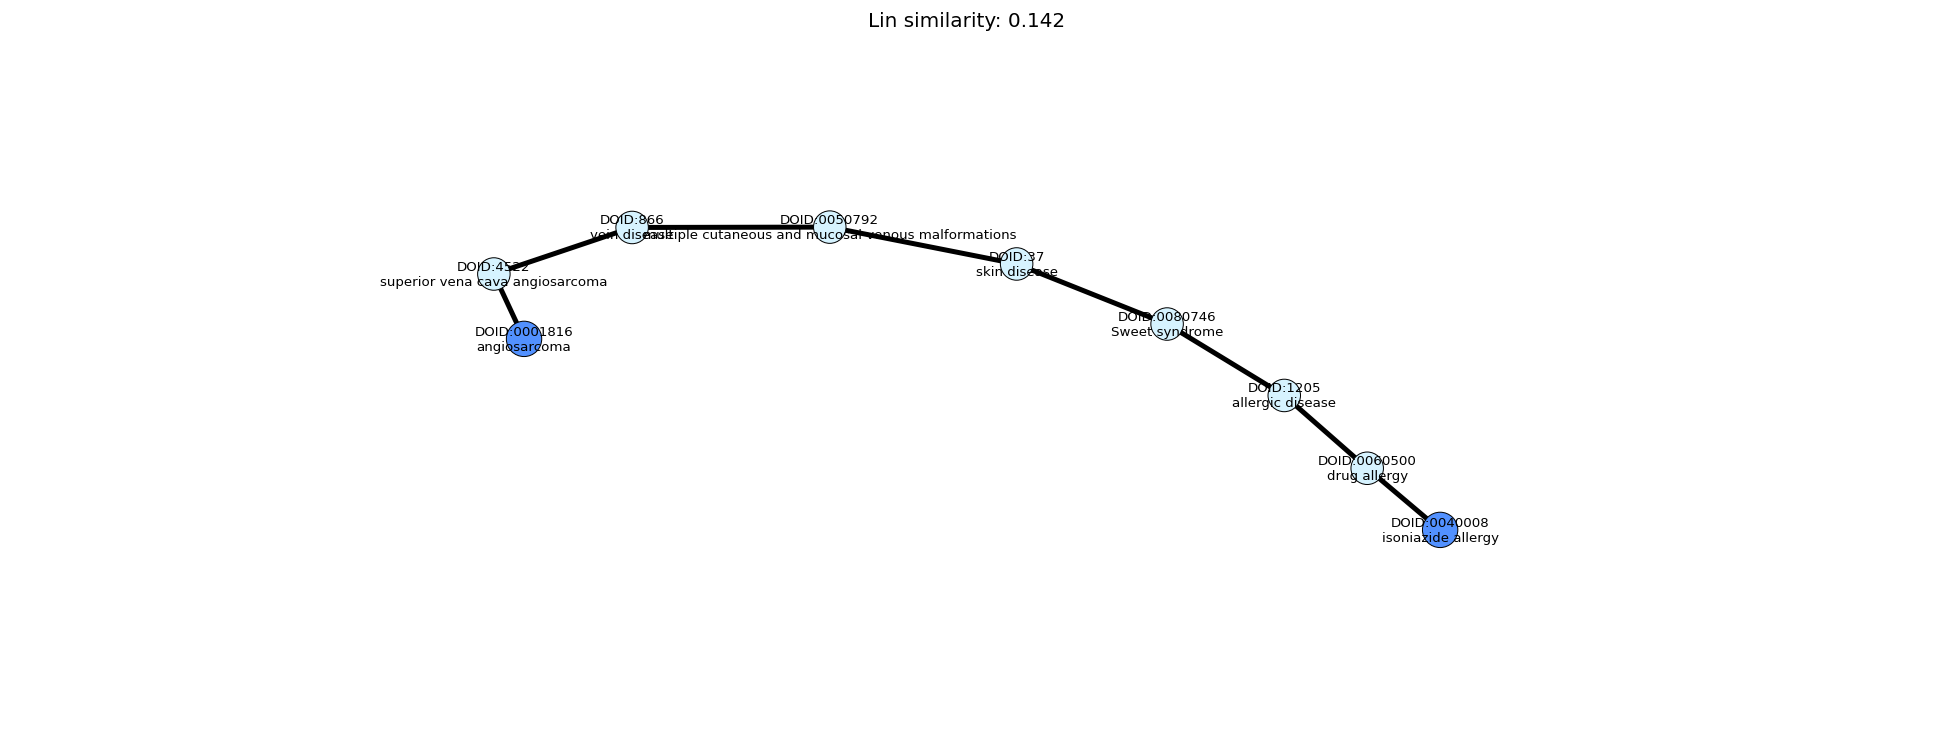

In [84]:
import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_do_shortest_path_with_lca(G, u, v, undirected=True, figsize=(16, 6), dpi=120, pad=1):
    H = G.to_undirected(as_view=True) if undirected else G
    path  = nx.shortest_path(H, u, v)
    edges = list(zip(path[:-1], path[1:]))

    # LCAs (assumes DAG edges child -> parent)
    A = set(nx.ancestors(G, u)) | {u}
    B = set(nx.ancestors(G, v)) | {v}
    C = A & B
    lcas = {a for a in C if not any(a != b and nx.has_path(G, a, b) for b in C)}
    lcas_on_path = {n for n in path if n in lcas}

    S = H.subgraph(path).copy()
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)

    pos = nx.spring_layout(S, seed=42)
    nx.draw_networkx_edges(S, pos, edgelist=edges, width=3, ax=ax)

    colors, sizes = [], []
    for n in path:
        if n in (u, v):         c, s = "#5291ff", 450
        elif n in lcas_on_path: c, s = "#ffd255", 520
        else:                   c, s = "#d6f3ff", 380
        colors.append(c); sizes.append(s)


    nx.draw_networkx_nodes(S, pos, nodelist=path, node_color=colors,
                           node_size=sizes, edgecolors="black", linewidths=0.6, ax=ax)
    labels = {n: f"{n}\n{G.nodes[n].get('name','')}".strip() for n in path}
    nx.draw_networkx_labels(S, pos, labels=labels, font_size=8, ax=ax)

    # expand axes so labels aren’t cropped
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    ax.set_xlim(xs.min()-pad, xs.max()+pad)
    ax.set_ylim(ys.min()-pad, ys.max()+pad)

    ax.axis("off")
    # # --- Legend: query nodes and MICA/LCA ---
    # legend_handles = [
    #     Line2D([0], [0], marker='o', linestyle='None',
    #            markerfacecolor="#5291ff", markeredgecolor="black",
    #            markersize=10, label="Query nodes"),
    #     Line2D([0], [0], marker='o', linestyle='None',
    #            markerfacecolor="#ffd255", markeredgecolor="black",
    #            markersize=11, label="MICA"),
    # ]
    # ax.legend(handles=legend_handles, loc="best", frameon=False)
    ax.set_title(f"Lin similarity: {do_df_ic.query(f'do1==\"{u}\" and do2==\"{v}\"')['lin'].values[0]:.3f}")

    return fig, ax

# plot_do_shortest_path_with_lca(do_graph, "DOID:8221", "DOID:8239", )

plot_do_shortest_path_with_lca(do_graph.reverse(), "DOID:0001816", "DOID:0040008" )

MICA: DOID:201


(<Figure size 480x480 with 1 Axes>,
 <Axes: title={'center': 'Lin similarity: 0.700'}>)

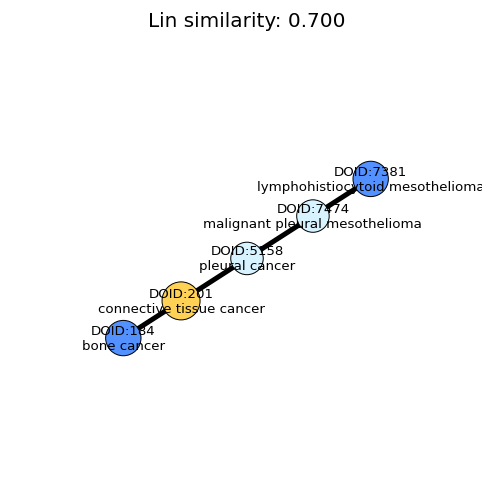

In [ ]:
def plot_do_shortest_path_with_lca(G, u, v, figsize=(4,4), dpi=120, pad=0.9):
    # collect ancestors (including self)
    A = set(nx.ancestors(G, u)) | {u}
    B = set(nx.ancestors(G, v)) | {v}
    common = A & B
    if not common:
        raise ValueError(f"No common ancestors found between {u} and {v}!")

    # find MICA (lowest common ancestor = one with no descendant also in common)
    mica = {a for a in common if not any(a != b and nx.has_path(G, a, b) for b in common)}
    mica = next(iter(mica))  # assume single MICA for simplicity

    print(f"MICA: {mica}")

    # now get the true directed paths (in G, child→parent direction)
    path_u = nx.shortest_path(G, mica, u )
    path_v = nx.shortest_path(G, mica,v)

    # merge both paths at the MICA
    path = path_u + path_v[::-1][1:]
    # path = path_u + path_v[::-1][1:]
    path = list(dict.fromkeys(path_u + path_v))  # merge but keep both u and v

    edges = list(zip(path[:-1], path[1:]))

    H = G.to_undirected(as_view=True)
    S = H.subgraph(path).copy()
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)
    pos = nx.spring_layout(S)

    nx.draw_networkx_edges(S, pos, width=3, ax=ax)

    colors, sizes = [], []
    for n in path:
        if n in (u, v):       c, s = "#5291ff", 450
        elif n == mica:       c, s = "#ffd255", 520
        else:                 c, s = "#d6f3ff", 380
        colors.append(c); sizes.append(s)

    nx.draw_networkx_nodes(S, pos, nodelist=path, node_color=colors,
                           node_size=sizes, edgecolors="black", linewidths=0.6, ax=ax)
    labels = {n: f"{n}\n{G.nodes[n].get('name','')}".strip() for n in path}
    nx.draw_networkx_labels(S, pos, labels=labels, font_size=8, ax=ax)

    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    ax.set_xlim(xs.min()-pad, xs.max()+pad)
    ax.set_ylim(ys.min()-pad, ys.max()+pad)
    ax.axis("off")
    ax.set_title(f"Lin similarity: {do_df_ic.query(f'do1==\"{u}\" and do2==\"{v}\"')['lin'].values[0]:.3f}")
    return fig, ax


# plot_do_shortest_path_with_lca(do_graph, "DOID:0001816", "DOID:0040008"  )
# plot_do_shortest_path_with_lca(do_graph, "DOID:8221", "DOID:8239", )

plot_do_shortest_path_with_lca(do_graph, "DOID:184", "DOID:7381", )


In [48]:
u = "DOID:6727"
v = "DOID:0040044"
print("Ancestors of", u, nx.ancestors(G, u))
print("Ancestors of", v, nx.ancestors(G, v))
print("Common ancestors:", set(nx.ancestors(G, u)) & set(nx.ancestors(G, v)))

Ancestors of DOID:6727 {'DOID:10155', 'DOID:7', 'DOID:5353', 'DOID:5295', 'DOID:77', 'DOID:5672', 'DOID:162', 'DOID:14566', 'DOID:3119', 'DOID:219', 'DOID:305', 'DOID:9256', 'DOID:0050686', 'DOID:0050687', 'DOID:4'}
Ancestors of DOID:0040044 {'DOID:7', 'DOID:1579', 'DOID:0060496', 'DOID:1205', 'DOID:9415', 'DOID:2914', 'DOID:1176', 'DOID:0050161', 'DOID:0080809', 'DOID:0080811', 'DOID:2841', 'DOID:0040041', 'DOID:4'}
Common ancestors: {'DOID:7', 'DOID:4'}


KeyboardInterrupt: 

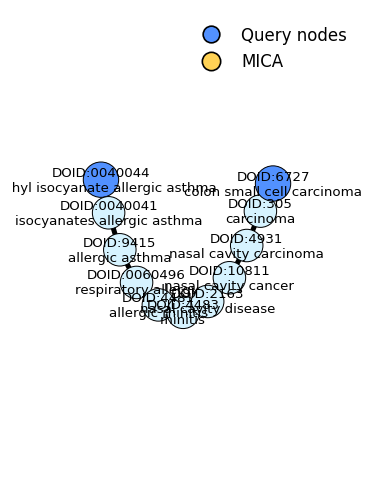

(0.0, 1.0, 0.0, 1.0)

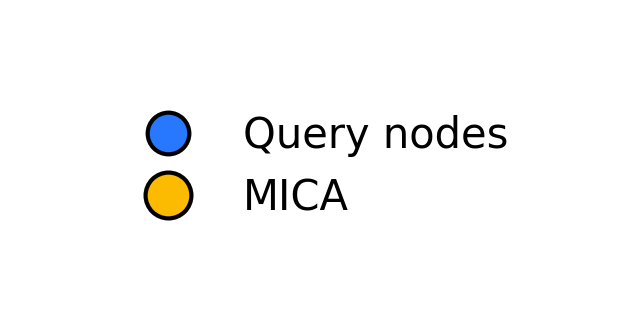

In [27]:
fig, ax = plt.subplots(figsize=(2, 1), dpi=300, constrained_layout=True)

# --- Legend: query nodes and MICA/LCA ---
legend_handles = [
       Line2D([0], [0], marker='o', linestyle='None',
              markerfacecolor="#2778ff", markeredgecolor="black",
              markersize=10, label="Query nodes"),
       Line2D([0], [0], marker='o', linestyle='None',
              markerfacecolor="#fcbb01", markeredgecolor="black",
              markersize=11, label="MICA"),
]
ax.legend(handles=legend_handles, loc="center", frameon=False)
ax.axis("off")

In [17]:
        if n in (u, v):         c, s = "#2778ff", 450
        elif n in lcas_on_path: c, s = "#fcbb01", 520
        else:                   c, s = "#d6f3ff", 380

NameError: name 'n' is not defined

In [42]:
adata.obs[adata.obs["tissue"]=="nan"]

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease
117,DSA00045.GSM6947279.Control,GSE223405,GSE223405,1132,1132,DSA00045,nan,19402,Control,Control,Prostate Cancer,RNA-Seq,D,Control,Control,Control
118,DSA00045.GSM6947280.Control,GSE223405,GSE223405,1132,1132,DSA00045,nan,19402,Control,Control,Prostate Cancer,RNA-Seq,D,Control,Control,Control
119,DSA00045.GSM6947281.Control,GSE223405,GSE223405,1132,1132,DSA00045,nan,19402,Control,Control,Prostate Cancer,RNA-Seq,D,Control,Control,Control
120,DSA00045.GSM6947291.Case,GSE223405,GSE223405,1132,1132,DSA00045,nan,19402,Prostate Cancer,Prostate Cancer,Prostate Cancer,RNA-Seq,D,DOID:10286,DOID:10286,prostate carcinoma
121,DSA00045.GSM6947292.Case,GSE223405,GSE223405,1132,1132,DSA00045,nan,19402,Prostate Cancer,Prostate Cancer,Prostate Cancer,RNA-Seq,D,DOID:10286,DOID:10286,prostate carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121022,DSA10298.GSM1131665.Case,GSE46517,GSE46517,878,878,DSA10298,nan,12004,Melanoma,Melanoma,Melanoma,Microarray,D,DOID:1909,DOID:1909,melanoma
121023,DSA10298.GSM1131666.Case,GSE46517,GSE46517,878,878,DSA10298,nan,12004,Melanoma,Melanoma,Melanoma,Microarray,D,DOID:1909,DOID:1909,melanoma
121024,DSA10298.GSM1131667.Case,GSE46517,GSE46517,878,878,DSA10298,nan,12004,Melanoma,Melanoma,Melanoma,Microarray,D,DOID:1909,DOID:1909,melanoma
121025,DSA10298.GSM1131668.Case,GSE46517,GSE46517,878,878,DSA10298,nan,12004,Melanoma,Melanoma,Melanoma,Microarray,D,DOID:1909,DOID:1909,melanoma


{'DOID:7', 'DOID:4'}


(<Figure size 360x480 with 1 Axes>,
 <Axes: title={'center': 'Path from DOID:0040044 to DOID:6727\nMICA: DOID:4'}>)

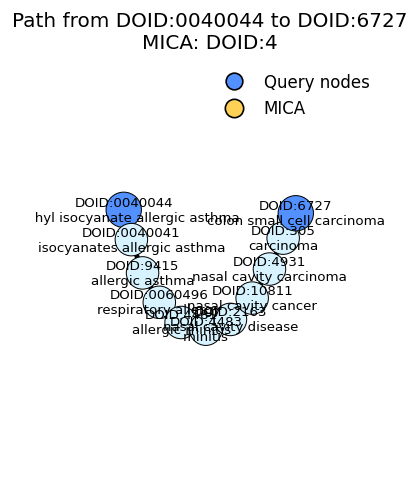

In [62]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def plot_do_shortest_path_with_lca(G, u, v, figsize=(3,4), dpi=120, pad=1):
    """
    Plots the (undirected) shortest path between two DOID nodes in the directed DO graph,
    and highlights the most informative common ancestor (MICA) in yellow.
    """
    # undirected path (pure connectivity)
    H = G.to_undirected(as_view=True)
    path = nx.shortest_path(H, u, v)
    edges = list(zip(path[:-1], path[1:]))

    # compute ancestors (direction: parent→child in DO, so reverse for ancestry)
    A = set(nx.ancestors(G, u)) | {u}
    B = set(nx.ancestors(G, v)) | {v}
    common = A & B
    if not common:
        mica = None
    else:
        print(common)
        # pick the deepest common ancestor (farthest from root)
        mica = max(common, key=lambda x: nx.shortest_path_length(G, x, u))

    # build subgraph for plotting
    S = H.subgraph(path).copy()
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)
    pos = nx.spring_layout(S, seed=42)
    nx.draw_networkx_edges(S, pos, edgelist=edges, width=3, ax=ax)

    # node colors
    colors, sizes = [], []
    for n in path:
        if n in (u, v):       c, s = "#5291ff", 450
        elif n == mica:       c, s = "#ffd255", 520
        else:                 c, s = "#d6f3ff", 380
        colors.append(c); sizes.append(s)

    nx.draw_networkx_nodes(S, pos, nodelist=path, node_color=colors,
                           node_size=sizes, edgecolors="black", linewidths=0.6, ax=ax)

    labels = {n: f"{n}\n{G.nodes[n].get('name','')}".strip() for n in path}
    nx.draw_networkx_labels(S, pos, labels=labels, font_size=8, ax=ax)

    # expand axes
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    ax.set_xlim(xs.min() - pad, xs.max() + pad)
    ax.set_ylim(ys.min() - pad, ys.max() + pad)
    ax.axis("off")

    # legend
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor="#5291ff", markeredgecolor="black",
               markersize=10, label="Query nodes"),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor="#ffd255", markeredgecolor="black",
               markersize=11, label="MICA"),
    ]
    ax.legend(handles=legend_handles, loc="best", frameon=False)

    ax.set_title(f"Path from {u} to {v}\nMICA: {mica}")
    return fig, ax

plot_do_shortest_path_with_lca(do_graph, "DOID:0040044", "DOID:6727" )

MICA: DOID:7


(<Figure size 720x720 with 1 Axes>,
 <Axes: title={'center': 'Directed paths to MICA: DOID:7'}>)

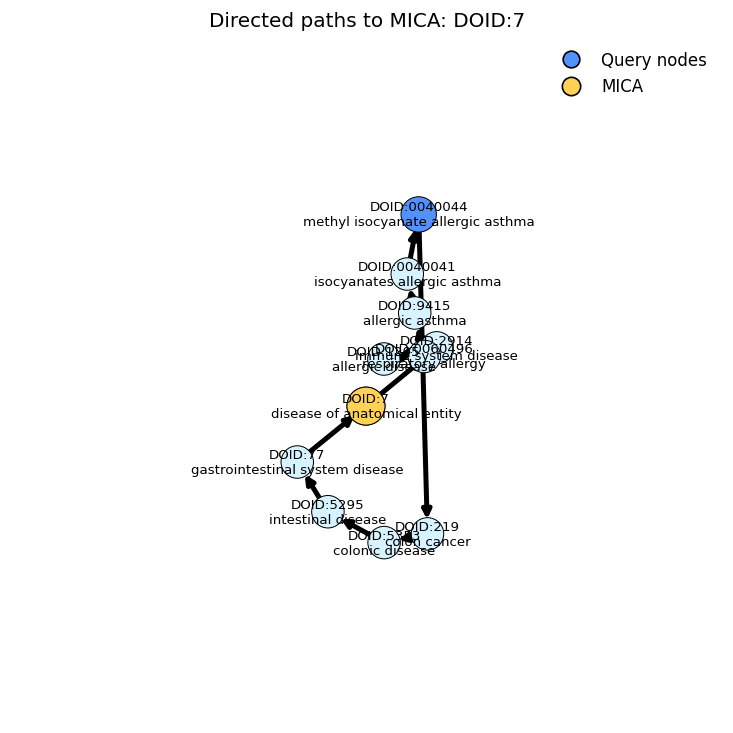

In [79]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def plot_do_shortest_path_with_lca(G, u, v, figsize=(6,6), dpi=120, pad=1):
    """
    Plots the directed paths from u and v to their MICA (lowest common ancestor)
    in a DAG where edges go parent -> child (as in DOID).
    """

    # work on reversed Gaph so edges go child -> parent (easier to trace ancestry)
    G = G

    # collect ancestors (including self)
    A = set(nx.ancestors(G, u)) | {u}
    B = set(nx.ancestors(G, v)) | {v}
    common = A & B
    if not common:
        raise ValueError(f"No common ancestors found between {u} and {v}!")

    # find MICA (lowest common ancestor = one with no descendant also in common)
    mica = {a for a in common if not any(a != b and nx.has_path(G, a, b) for b in common)}
    mica = next(iter(mica))  # assume single MICA for simplicity

    print(f"MICA: {mica}")

    # now get the true directed paths (in G, child→parent direction)
    path_u = nx.shortest_path(G, mica, u )
    path_v = nx.shortest_path(G, mica,v)

    # merge both paths at the MICA
    path = path_u + path_v[::-1][1:]
    edges = list(zip(path[:-1], path[1:]))

    # build subGaph for visualization (directed)
    S = G.subgraph(path).copy()

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)
    pos = nx.spring_layout(S, seed=42)

    nx.draw_networkx_edges(S, pos, edgelist=edges, width=3, arrows=True, ax=ax)

    # color and size map
    colors, sizes = [], []
    for n in path:
        if n in (u, v):
            c, s = "#5291ff", 450
        elif n == mica:
            c, s = "#ffd255", 520
        else:
            c, s = "#d6f3ff", 380
        colors.append(c); sizes.append(s)

    nx.draw_networkx_nodes(S, pos, nodelist=path, node_color=colors,
                           node_size=sizes, edgecolors="black", linewidths=0.6, ax=ax)
    labels = {n: f"{n}\n{G.nodes[n].get('name','')}".strip() for n in path}
    nx.draw_networkx_labels(S, pos, labels=labels, font_size=8, ax=ax)

    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    ax.set_xlim(xs.min() - pad, xs.max() + pad)
    ax.set_ylim(ys.min() - pad, ys.max() + pad)
    ax.axis("off")

    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor="#5291ff", markeredgecolor="black",
               markersize=10, label="Query nodes"),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor="#ffd255", markeredgecolor="black",
               markersize=11, label="MICA"),
    ]
    ax.legend(handles=legend_handles, loc="best", frameon=False)

    ax.set_title(f"Directed paths to MICA: {mica}")
    return fig, ax

plot_do_shortest_path_with_lca(do_graph, "DOID:0040044", "DOID:6727" )

In [75]:
nx.ancestors(do_graph, "DOID:0040044")

{'DOID:0040041',
 'DOID:0050161',
 'DOID:0060496',
 'DOID:0080809',
 'DOID:0080811',
 'DOID:1176',
 'DOID:1205',
 'DOID:1579',
 'DOID:2841',
 'DOID:2914',
 'DOID:4',
 'DOID:7',
 'DOID:9415'}

In [77]:
nx.shortest_path(do_graph, "DOID:7","DOID:0040044", )

['DOID:7',
 'DOID:2914',
 'DOID:1205',
 'DOID:0060496',
 'DOID:9415',
 'DOID:0040041',
 'DOID:0040044']

In [58]:
nx.ancestors(G, v)

{'DOID:0040041',
 'DOID:0050161',
 'DOID:0060496',
 'DOID:0080809',
 'DOID:0080811',
 'DOID:1176',
 'DOID:1205',
 'DOID:1579',
 'DOID:2841',
 'DOID:2914',
 'DOID:4',
 'DOID:7',
 'DOID:9415'}